# DASVO TartanAir RGB-D Validation Split

This notebook provides a compact EDA pass for the Kaggle dataset release used by the DASVO paper. It scans the packaged subset, validates sequence completeness, and visualizes sequence lengths, difficulty balance, and a few RGB/depth examples.

In [9]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)

DEFAULT_DATASET_ROOT = Path('/kaggle/input/dasvo-tartanair-rgbd-validation-split/tartanair')
DATASET_ROOT = Path(os.environ.get('DASVO_DATASET_ROOT', DEFAULT_DATASET_ROOT))
DATASET_ROOT

PosixPath('/kaggle/input/dasvo-tartanair-rgbd-validation-split/tartanair')

In [11]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f'Dataset root not found: {DATASET_ROOT}. '
        'Set DASVO_DATASET_ROOT or attach the Kaggle dataset first.'
    )

records = []
for pose_path in sorted(DATASET_ROOT.rglob('pose_left.txt')):
    env, difficulty, sequence, _ = pose_path.relative_to(DATASET_ROOT).parts
    image_dir = pose_path.parent / 'image_left'
    depth_dir = pose_path.parent / 'depth_left'
    image_files = sorted(image_dir.glob('*.png'))
    depth_files = sorted(depth_dir.glob('*.npy'))
    pose_rows = sum(1 for _ in pose_path.open('r', encoding='utf-8'))
    records.append({
        'environment': env,
        'difficulty': difficulty,
        'sequence': sequence,
        'sequence_id': f'{env}/{difficulty}/{sequence}',
        'image_count': len(image_files),
        'depth_count': len(depth_files),
        'pose_rows': pose_rows,
        'image_dir': image_dir,
        'depth_dir': depth_dir,
        'pose_path': pose_path,
    })

df = pd.DataFrame(records).sort_values(['environment', 'difficulty', 'sequence']).reset_index(drop=True)
df['is_aligned'] = (df['image_count'] == df['depth_count']) & (df['depth_count'] == df['pose_rows'])
df.head()

,environment,difficulty,sequence,sequence_id,image_count,depth_count,pose_rows,image_dir,depth_dir,pose_path,is_aligned
0,abandonedfactory,Easy,P011,abandonedfactory/Easy/P011,3084,3084,3084,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,True
1,abandonedfactory,Hard,P011,abandonedfactory/Hard/P011,634,634,634,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,True
2,abandonedfactory_night,Easy,P013,abandonedfactory_night/Easy/P013,2813,2813,2813,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,True
3,abandonedfactory_night,Hard,P014,abandonedfactory_night/Hard/P014,460,460,460,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,True
4,amusement,Easy,P008,amusement/Easy/P008,645,645,645,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,/kaggle/input/dasvo-tartanair-rgbd-validation-...,True


In [12]:
summary = pd.Series({
    'sequences': int(len(df)),
    'environments': int(df['environment'].nunique()),
    'easy_sequences': int((df['difficulty'] == 'Easy').sum()),
    'hard_sequences': int((df['difficulty'] == 'Hard').sum()),
    'total_frames': int(df['pose_rows'].sum()),
    'min_sequence_length': int(df['pose_rows'].min()),
    'max_sequence_length': int(df['pose_rows'].max()),
    'mean_sequence_length': float(df['pose_rows'].mean()),
    'all_sequences_aligned': bool(df['is_aligned'].all()),
})
summary.to_frame('value')

,value
sequences,32
environments,18
easy_sequences,17
hard_sequences,15
total_frames,26650
min_sequence_length,300
max_sequence_length,3084
mean_sequence_length,832.8125
all_sequences_aligned,True


In [13]:
environment_summary = (
    df.groupby('environment', as_index=False)
      .agg(
          sequences=('sequence_id', 'count'),
          total_frames=('pose_rows', 'sum'),
          min_frames=('pose_rows', 'min'),
          max_frames=('pose_rows', 'max'),
          mean_frames=('pose_rows', 'mean'),
      )
      .sort_values('total_frames', ascending=False)
)
environment_summary

,environment,sequences,total_frames,min_frames,max_frames,mean_frames
0,abandonedfactory,2,3718,634,3084,1859.0
1,abandonedfactory_night,2,3273,460,2813,1636.5
12,oldtown,2,3111,1215,1896,1555.5
5,gascola,2,2211,764,1447,1105.5
8,neighborhood,2,1969,880,1089,984.5
17,westerndesert,2,1294,303,991,647.0
11,office2,2,1267,558,709,633.5
15,seasonsforest_winter,2,1196,462,734,598.0
2,amusement,2,1195,550,645,597.5
9,ocean,2,1108,513,595,554.0


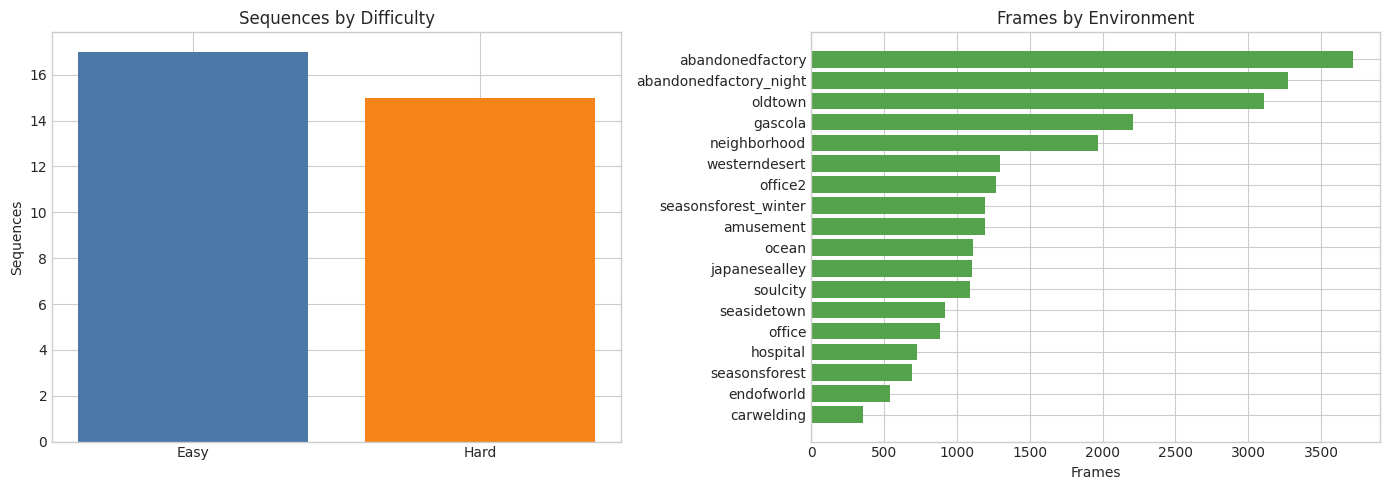

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

difficulty_counts = df['difficulty'].value_counts().reindex(['Easy', 'Hard']).fillna(0)
axes[0].bar(difficulty_counts.index, difficulty_counts.values, color=['#4C78A8', '#F58518'])
axes[0].set_title('Sequences by Difficulty')
axes[0].set_ylabel('Sequences')

env_plot = environment_summary.sort_values('total_frames')
axes[1].barh(env_plot['environment'], env_plot['total_frames'], color='#54A24B')
axes[1].set_title('Frames by Environment')
axes[1].set_xlabel('Frames')

plt.tight_layout()
plt.show()

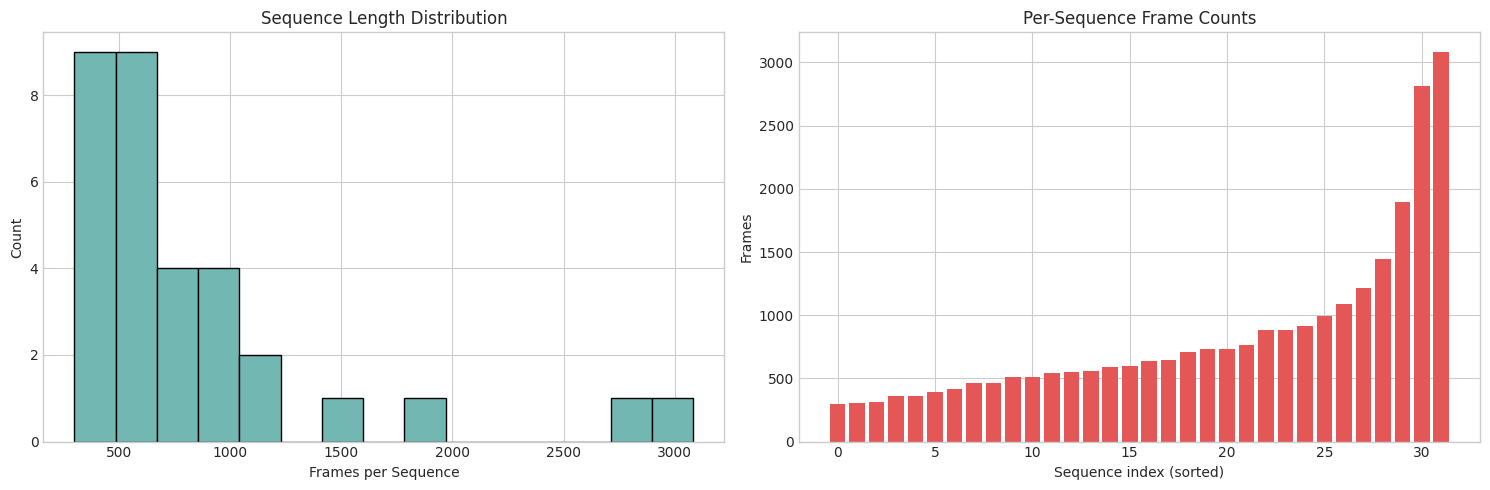

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['pose_rows'], bins=15, color='#72B7B2', edgecolor='black')
axes[0].set_title('Sequence Length Distribution')
axes[0].set_xlabel('Frames per Sequence')
axes[0].set_ylabel('Count')

plot_df = df.sort_values('pose_rows').reset_index(drop=True)
axes[1].bar(range(len(plot_df)), plot_df['pose_rows'], color='#E45756')
axes[1].set_title('Per-Sequence Frame Counts')
axes[1].set_xlabel('Sequence index (sorted)')
axes[1].set_ylabel('Frames')

plt.tight_layout()
plt.show()

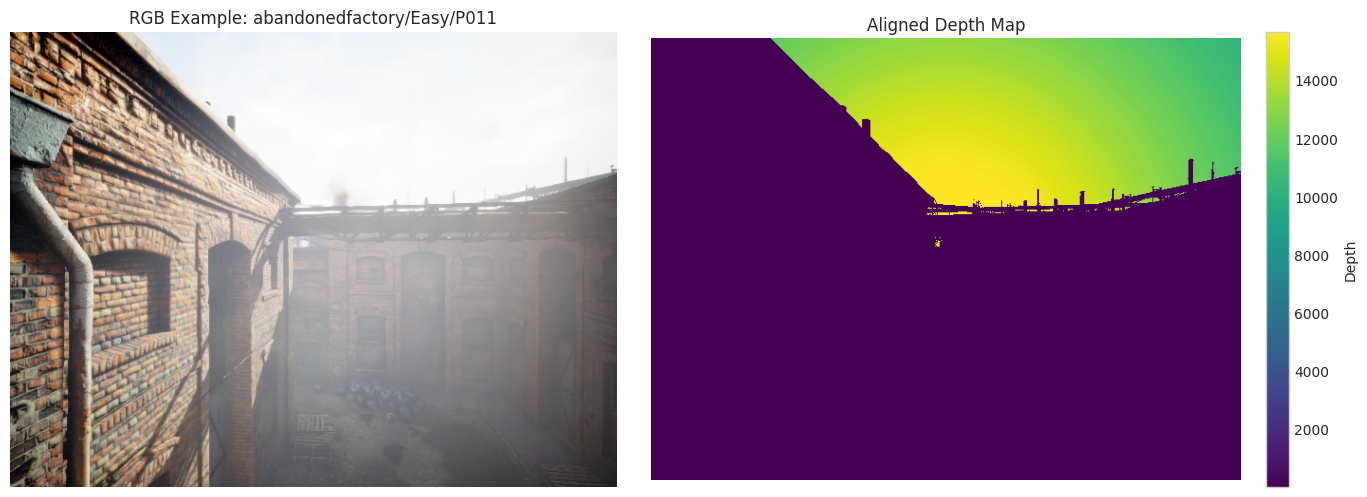

Depth min: 1.7509765625
Depth max: 16288.0
Depth mean: 3220.18896484375


In [16]:
sample_row = df.sort_values('pose_rows', ascending=False).iloc[0]
sample_image_path = sorted(sample_row['image_dir'].glob('*.png'))[0]
sample_depth_path = sorted(sample_row['depth_dir'].glob('*.npy'))[0]

rgb = np.array(Image.open(sample_image_path))
depth = np.load(sample_depth_path)
depth_vis = np.clip(depth, 0, np.percentile(depth, 99))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb)
axes[0].set_title(f'RGB Example: {sample_row["sequence_id"]}')
axes[0].axis('off')

depth_plot = axes[1].imshow(depth_vis, cmap='viridis')
axes[1].set_title('Aligned Depth Map')
axes[1].axis('off')
fig.colorbar(depth_plot, ax=axes[1], fraction=0.046, pad=0.04, label='Depth')

plt.tight_layout()
plt.show()

print('Depth min:', float(np.min(depth)))
print('Depth max:', float(np.max(depth)))
print('Depth mean:', float(np.mean(depth)))

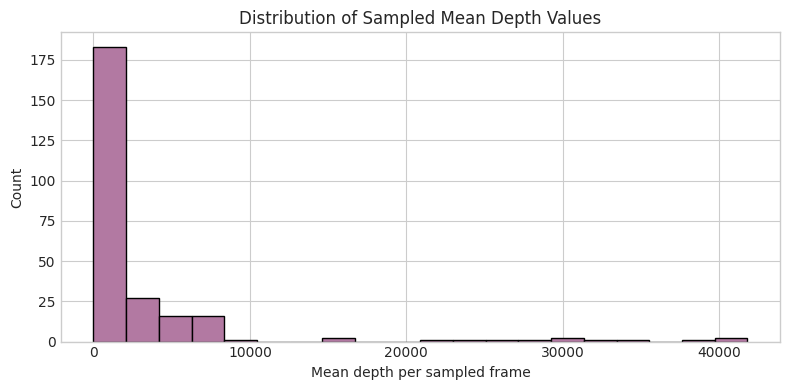

count      256.000000
mean      2821.282760
std       6767.687189
min          0.975938
25%         10.018304
50%        150.509308
75%       2990.338440
max      41792.433594
dtype: float64

In [17]:
sampled_depth_paths = []
for _, row in df.iterrows():
    sequence_depths = sorted(row['depth_dir'].glob('*.npy'))
    step = max(1, len(sequence_depths) // 8)
    sampled_depth_paths.extend(sequence_depths[::step][:8])

depth_means = []
for depth_path in sampled_depth_paths:
    depth_means.append(float(np.load(depth_path).mean()))

plt.figure(figsize=(8, 4))
plt.hist(depth_means, bins=20, color='#B279A2', edgecolor='black')
plt.title('Distribution of Sampled Mean Depth Values')
plt.xlabel('Mean depth per sampled frame')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

pd.Series(depth_means).describe()

## Notes for Kaggle

- The packaged split intentionally excludes downloader markers, extracted archives, and right-camera pose files.
- `pose_left.txt` provides one pose row per RGB/depth frame.
- The dataset is aimed at reproducible sparse visual odometry evaluation rather than full TartanAir redistribution.